# BERT Alignment via Real IEMOCAP Transcripts

This notebook is the **transcript-based** companion to `bert_alignment.ipynb`.
Where the label-word version asks *"how close is speech geometry to a 4-word
emotion vocabulary?"*, this version asks the stricter question:

> **How close is the per-utterance speech representation at layer L to the
> per-utterance BERT representation of the exact words the speaker said?**

### Why this is only IEMOCAP

IEMOCAP is the only dataset in our corpus with genuinely free-form per-utterance
transcripts (5,460 unique sentences). RAVDESS, EmoDB, SAVEE, AESDD, MESD and MSP-Podcast
either use a handful of fixed sentences or ship no transcripts at all. So this
notebook is scoped to **6 speech encoders x 1 dataset x 25 layers = 150 per-layer
alignment measurements**.

### Pipeline

1. Parse `IEMOCAP_full_release/Session{1..5}/dialog/transcriptions/*.txt` into a
   `utterance_id -> text` dict (~10K utterances).
2. Load Nima's frozen IEMOCAP hidden states + filenames for every speech model.
3. Match speech samples to transcripts via `utterance_id == filename.replace('.wav', '')`.
   One dialog file in Session2 is corrupt (null-byte filled); those 26 samples
   are dropped. Remaining: ~5,434/5,460 samples (99.5%).
4. BERT-encode every transcript once with `bert-base-uncased` (mean-pool last
   hidden state).
5. For each model x layer, compute:
   - **Linear CKA**: per-utterance representation similarity
   - **Procrustes alignment**: orthogonal rotation between class centroids
   - **Centroid-transfer accuracy**: classify speech by nearest mapped text centroid

### Expected finding
Speech alignment with real text should **peak in mid-to-late transformer layers**
(the same layers where emotion-class probes peak). If alignment instead peaks at
layer 0 or the very last layer, that tells us the speech encoder is storing
acoustics there, not lexical content, which is itself a useful result.


## 1. Imports & Device

In [1]:
import os
import re
import json
import glob
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.linalg import orthogonal_procrustes
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')


Using device: mps


## 2. Configuration & Path Resolution

In [2]:
# ============================================================
# PATHS
# ============================================================
PROJECT_ROOT = '/Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final'
NIMA_EMBEDDINGS_ROOT = os.path.join(PROJECT_ROOT, 'embeddings_npyfiles')
EXP3_DIR = os.path.join(PROJECT_ROOT, 'EXP3', 'embeddings')
EXP3_2_DIR = os.path.join(PROJECT_ROOT, 'EXP3 2', 'embeddings')
IEMOCAP_ROOT = os.path.join(PROJECT_ROOT, 'my_code', 'data', 'IEMOCAP_full_release')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'my_code', 'results', 'bert_alignment_transcripts')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================
# 6 SPEECH MODELS (IEMOCAP-only)
# ============================================================
MODELS = ['wav2vec2', 'HuBERT', 'Whisper', 'WavLM', 'MERT', 'w2v-BERT']
DATASET = 'IEMOCAP'
NUM_LAYERS = 25  # CNN + 24 transformer blocks

# ============================================================
# EMBEDDING FILE INDEX, same walker used in layer_mixer/lora
# ============================================================
_EMB_PATTERN = re.compile(
    r'^(hidden_states|filenames|labels)_([A-Za-z0-9\-]+)_([A-Za-z0-9\-]+?)(?:_SNR(\d+))?\.npy$'
)


def _build_embedding_index(verbose=False):
    index = {}
    if os.path.isdir(NIMA_EMBEDDINGS_ROOT):
        for top in sorted(os.listdir(NIMA_EMBEDDINGS_ROOT)):
            if not top.startswith('Embedding-Files'):
                continue
            top_path = os.path.join(NIMA_EMBEDDINGS_ROOT, top)
            if not os.path.isdir(top_path):
                continue
            for sub in ('clean-embeddings', 'noisy-embeddings'):
                emb_dir = os.path.join(top_path, sub, 'embeddings')
                if not os.path.isdir(emb_dir):
                    continue
                for fname in os.listdir(emb_dir):
                    if not fname.endswith('.npy'):
                        continue
                    m = _EMB_PATTERN.match(fname)
                    if not m:
                        continue
                    key = (
                        m.group(1), m.group(2), m.group(3),
                        f'SNR{m.group(4)}' if m.group(4) else 'clean',
                    )
                    if key not in index:
                        index[key] = os.path.join(emb_dir, fname)
    for legacy in (EXP3_2_DIR, EXP3_DIR):
        if not os.path.isdir(legacy):
            continue
        for fname in os.listdir(legacy):
            m = _EMB_PATTERN.match(fname)
            if not m:
                continue
            key = (
                m.group(1), m.group(2), m.group(3),
                f'SNR{m.group(4)}' if m.group(4) else 'clean',
            )
            if key not in index:
                index[key] = os.path.join(legacy, fname)
    if verbose:
        iem = {k: v for k, v in index.items() if k[2] == 'IEMOCAP' and k[3] == 'clean'}
        print(f'IEMOCAP (clean) entries indexed: {len(iem)}')
    return index


EMB_INDEX = _build_embedding_index(verbose=True)


def get_hidden_states(model):
    key = ('hidden_states', model, DATASET, 'clean')
    if key not in EMB_INDEX:
        raise FileNotFoundError(f'Missing IEMOCAP hidden states for {model}')
    return EMB_INDEX[key]


def get_filenames(model):
    key = ('filenames', model, DATASET, 'clean')
    if key not in EMB_INDEX:
        # Fall back to any other model's filenames (they are shared across models)
        for other in MODELS:
            alt = ('filenames', other, DATASET, 'clean')
            if alt in EMB_INDEX:
                return EMB_INDEX[alt]
        raise FileNotFoundError(f'Missing IEMOCAP filenames for {model}')
    return EMB_INDEX[key]


def get_labels(model):
    key = ('labels', model, DATASET, 'clean')
    if key not in EMB_INDEX:
        for other in MODELS:
            alt = ('labels', other, DATASET, 'clean')
            if alt in EMB_INDEX:
                return EMB_INDEX[alt]
        raise FileNotFoundError(f'Missing IEMOCAP labels for {model}')
    return EMB_INDEX[key]


# ============================================================
# PLOT STYLE
# ============================================================
PLOT_STYLE = {
    'speech_color': '#2196F3',
    'text_color': '#FF5722',
    'figsize_single': (10, 5),
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_fontsize': 10,
    'legend_fontsize': 11,
    'grid_alpha': 0.3,
    'dpi': 300,
}
LAYER_LABELS = ['CNN'] + [str(i) for i in range(1, 25)]

print()
print(f'Models   ({len(MODELS)}): {MODELS}')
print(f'Dataset: {DATASET}')
print(f'IEMOCAP transcripts root: {IEMOCAP_ROOT}')


IEMOCAP (clean) entries indexed: 18

Models   (6): ['wav2vec2', 'HuBERT', 'Whisper', 'WavLM', 'MERT', 'w2v-BERT']
Dataset: IEMOCAP
IEMOCAP transcripts root: /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/data/IEMOCAP_full_release


## 3. Parse IEMOCAP Transcriptions

Every IEMOCAP dialog file has one line per utterance:

```
Ses01F_impro01_F000 [006.2901-008.2357]: Excuse me.
Ses01F_impro01_M000 [007.5712-010.4750]: Do you have your forms?
```

We extract `(utterance_id, text)` pairs. One Session2 file is corrupt (null bytes),
so those ~26 samples are dropped silently.


In [3]:
TRANSCRIPT_RE = re.compile(r'^(\S+)\s+\[[\d.]+-[\d.]+\]:\s*(.*)$')

def parse_iemocap_transcripts(root):
    utt2text = {}
    n_files = 0
    n_corrupt = 0
    for session in sorted(os.listdir(root)):
        tdir = os.path.join(root, session, 'dialog', 'transcriptions')
        if not os.path.isdir(tdir):
            continue
        for txt in sorted(os.listdir(tdir)):
            if not txt.endswith('.txt'):
                continue
            fpath = os.path.join(tdir, txt)
            try:
                with open(fpath, encoding='utf-8') as f:
                    content = f.read()
                if '\x00' in content:
                    n_corrupt += 1
                    continue
                for line in content.splitlines():
                    m = TRANSCRIPT_RE.match(line.strip())
                    if m:
                        utt2text[m.group(1)] = m.group(2).strip()
            except (UnicodeDecodeError, OSError):
                n_corrupt += 1
                continue
            n_files += 1
    return utt2text, n_files, n_corrupt


utt2text, n_dialog, n_corrupt = parse_iemocap_transcripts(IEMOCAP_ROOT)
print(f'Parsed {n_dialog} dialog files ({n_corrupt} corrupt)')
print(f'Total unique utterance IDs: {len(utt2text)}')
print()
print('Sample transcripts:')
for k in list(utt2text)[:5]:
    print(f'  {k}: {utt2text[k][:70]!r}')


Parsed 150 dialog files (1 corrupt)
Total unique utterance IDs: 10040

Sample transcripts:
  Ses01F_impro01_F000: 'Excuse me.'
  Ses01F_impro01_M000: 'Do you have your forms?'
  Ses01F_impro01_F001: 'Yeah.'
  Ses01F_impro01_M001: 'Let me see them.'
  Ses01F_impro01_F002: 'Is there a problem?'


## 4. Match Speech Samples to Transcripts

Every speech model ships the same 5,460 IEMOCAP filenames (in the same order).
We load one model's filenames + labels, build the speech->text mapping, and then
drop any sample whose transcript is missing.


In [4]:
# Load filenames + labels (both are shared across all 6 models, so pick any)
fn_path = get_filenames(MODELS[0])
lb_path = get_labels(MODELS[0])
filenames_all = np.load(fn_path, allow_pickle=True)
labels_all = np.load(lb_path, allow_pickle=True)
print(f'Total IEMOCAP samples: {len(filenames_all)}')

# Match filenames to transcripts
utt_ids = [str(f).replace('.wav', '') for f in filenames_all]
keep_mask = np.array([u in utt2text for u in utt_ids])
n_keep = int(keep_mask.sum())
print(f'Matched to transcripts: {n_keep}/{len(filenames_all)} ({100 * n_keep / len(filenames_all):.2f}%)')

# Build aligned arrays: filenames, labels, transcripts (in the original order, masked)
kept_filenames = filenames_all[keep_mask]
kept_labels = labels_all[keep_mask]
kept_transcripts = np.array([utt2text[str(f).replace('.wav', '')] for f in kept_filenames], dtype=object)
KEEP_INDICES = np.where(keep_mask)[0]

# Quick sanity checks
print()
print('First 3 aligned samples:')
for i in range(3):
    print(f'  [{i}] file={kept_filenames[i]}  label={kept_labels[i]}  text={kept_transcripts[i][:70]!r}')

# Label encode (shared across all models)
le = LabelEncoder()
y = le.fit_transform(kept_labels)
print()
print(f'Classes: {list(le.classes_)}')
print(f'Class counts: {dict(zip(le.classes_, np.bincount(y)))}')


Total IEMOCAP samples: 5460
Matched to transcripts: 5434/5460 (99.52%)

First 3 aligned samples:
  [0] file=Ses01F_impro01_F000.wav  label=neu  text='Excuse me.'
  [1] file=Ses01F_impro01_F001.wav  label=neu  text='Yeah.'
  [2] file=Ses01F_impro01_F002.wav  label=neu  text='Is there a problem?'

Classes: [np.str_('ang'), np.str_('hap'), np.str_('neu'), np.str_('sad')]
Class counts: {np.str_('ang'): np.int64(1085), np.str_('hap'): np.int64(1618), np.str_('neu'): np.int64(1659), np.str_('sad'): np.int64(1072)}


## 5. BERT-Encode Every Transcript

Use `bert-base-uncased` (12 layers, 768-dim). Mean-pool the last hidden state over
non-pad tokens for every sentence. Cache to disk because this is the most expensive
one-shot computation in the notebook (~1-2 min on MPS for 5,434 sentences).


In [5]:
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_CACHE_PATH = os.path.join(RESULTS_DIR, f'bert_iemocap_{BERT_MODEL_NAME}.npy')
BERT_MAX_LEN = 64
BERT_BATCH = 32

if os.path.exists(BERT_CACHE_PATH):
    print(f'Loading cached BERT embeddings from {BERT_CACHE_PATH}')
    text_embeddings = np.load(BERT_CACHE_PATH)
else:
    print(f'Computing BERT embeddings for {len(kept_transcripts)} sentences...')
    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    bert = AutoModel.from_pretrained(BERT_MODEL_NAME).to(DEVICE).eval()

    all_vecs = []
    with torch.no_grad():
        for i in range(0, len(kept_transcripts), BERT_BATCH):
            batch_texts = [str(t) for t in kept_transcripts[i:i+BERT_BATCH]]
            enc = tokenizer(
                batch_texts,
                padding=True, truncation=True, max_length=BERT_MAX_LEN,
                return_tensors='pt',
            ).to(DEVICE)
            out = bert(**enc)
            last = out.last_hidden_state                     # (B, T, 768)
            mask = enc['attention_mask'].unsqueeze(-1).float()
            pooled = (last * mask).sum(1) / mask.sum(1).clamp(min=1.0)
            all_vecs.append(pooled.cpu().numpy())
            if (i // BERT_BATCH) % 20 == 0:
                print(f'  {i+len(batch_texts)}/{len(kept_transcripts)}')
    text_embeddings = np.concatenate(all_vecs, axis=0).astype(np.float32)
    np.save(BERT_CACHE_PATH, text_embeddings)
    print(f'Saved {BERT_CACHE_PATH}')

print(f'Text embeddings shape: {text_embeddings.shape}')


Loading cached BERT embeddings from /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/bert_iemocap_bert-base-uncased.npy
Text embeddings shape: (5434, 768)


## 6. Alignment Metrics (same as label-word version)

Three complementary measures, all operating on `(N, D_speech)` speech vs
`(N, D_text)` text matrices, with class centroids derived by label-mean pooling:

- **Linear CKA**: Frobenius-formulation kernel alignment
- **Procrustes alignment**: orthogonal rotation between class centroids
- **Centroid-transfer accuracy**: classify speech by nearest mapped text centroid


In [6]:
def center(X):
    return X - X.mean(axis=0, keepdims=True)


def linear_cka(X, Y):
    Xc = center(X).astype(np.float64)
    Yc = center(Y).astype(np.float64)
    num = np.linalg.norm(Yc.T @ Xc, ord='fro') ** 2
    den = np.linalg.norm(Xc.T @ Xc, ord='fro') * np.linalg.norm(Yc.T @ Yc, ord='fro')
    return float(num / den) if den > 1e-12 else 0.0


def procrustes_alignment(A_centroids, B_centroids):
    A = center(A_centroids)
    B = center(B_centroids)
    k = min(A.shape[0], A.shape[1], B.shape[1])
    Ua, Sa, _ = np.linalg.svd(A, full_matrices=False)
    Ub, Sb, _ = np.linalg.svd(B, full_matrices=False)
    A_red = Ua[:, :k] * Sa[:k]
    B_red = Ub[:, :k] * Sb[:k]
    A_norm = A_red / (np.linalg.norm(A_red) + 1e-12)
    B_norm = B_red / (np.linalg.norm(B_red) + 1e-12)
    R, _ = orthogonal_procrustes(A_norm, B_norm)
    disparity = float(np.linalg.norm(A_norm @ R - B_norm) ** 2)
    return disparity, max(0.0, min(1.0, 1.0 - disparity / 2.0))


def centroid_transfer_accuracy(X_speech, y, text_centroids, speech_centroids):
    W, *_ = np.linalg.lstsq(text_centroids, speech_centroids, rcond=None)
    mapped = text_centroids @ W
    dists = np.linalg.norm(X_speech[:, None, :] - mapped[None, :, :], axis=2)
    preds = dists.argmin(axis=1)
    return float(accuracy_score(y, preds))


def run_alignment_for_layer(X_layer, y, text_vecs,
                            speech_centroids, text_centroids):
    return {
        'cka': linear_cka(X_layer, text_vecs),
        'procrustes': procrustes_alignment(speech_centroids, text_centroids)[1],
        'centroid_transfer': centroid_transfer_accuracy(
            X_layer, y, text_centroids, speech_centroids,
        ),
    }


print('Alignment metric functions defined.')


Alignment metric functions defined.


## 7. Run 6-Model x 25-Layer Alignment

For each speech encoder, load its IEMOCAP hidden states, drop the unmatched
samples, and measure alignment against `text_embeddings` at every layer.

Class centroids are computed *per layer* on the speech side (they shift as
information moves through the network) but are *fixed* on the text side
(BERT encoding is computed once, outside the loop).


In [7]:
# Text-side class centroids (computed once)
class_text_centroids = np.stack([
    text_embeddings[y == c].mean(axis=0) for c in range(len(le.classes_))
])  # (k, 768)
print(f'Text class centroids shape: {class_text_centroids.shape}')


def run_experiment(model):
    hs_path = get_hidden_states(model)
    hs_all = np.load(hs_path, mmap_mode='r')   # (5460, 25, 1024)
    if hs_all.shape[0] != len(filenames_all):
        raise ValueError(
            f'{model}: hidden states have {hs_all.shape[0]} samples, '
            f'but filenames have {len(filenames_all)}'
        )
    # Drop unmatched rows
    hs = np.asarray(hs_all[KEEP_INDICES, :, :], dtype=np.float32)
    per_layer = []
    for layer_idx in range(NUM_LAYERS):
        X_layer = hs[:, layer_idx, :]
        # Speech class centroids at this layer
        speech_centroids = np.stack([
            X_layer[y == c].mean(axis=0) for c in range(len(le.classes_))
        ])
        metrics = run_alignment_for_layer(
            X_layer, y, text_embeddings,
            speech_centroids, class_text_centroids,
        )
        per_layer.append(metrics)
    return {
        'model': model,
        'num_samples': int(len(y)),
        'classes': list(le.classes_),
        'cka': np.array([m['cka'] for m in per_layer]),
        'procrustes': np.array([m['procrustes'] for m in per_layer]),
        'centroid_transfer': np.array([m['centroid_transfer'] for m in per_layer]),
    }


alignment_results = {}
for model in MODELS:
    try:
        print(f'Running {model}...', end=' ', flush=True)
        res = run_experiment(model)
        alignment_results[model] = res
        best_l = int(np.argmax(res['centroid_transfer']))
        print(
            f'OK ({res["num_samples"]} samples, '
            f'best xfer layer={best_l} acc={res["centroid_transfer"][best_l]:.3f}, '
            f'best CKA={res["cka"].max():.3f} @ layer={int(np.argmax(res["cka"]))})'
        )
    except Exception as e:
        print(f'FAILED: {e}')

print()
print(f'Completed {len(alignment_results)}/{len(MODELS)} experiments.')


Text class centroids shape: (4, 768)
Running wav2vec2... 

OK (5434 samples, best xfer layer=5 acc=0.462, best CKA=0.277 @ layer=21)
Running HuBERT... 

OK (5434 samples, best xfer layer=4 acc=0.434, best CKA=0.262 @ layer=13)
Running Whisper... 

OK (5434 samples, best xfer layer=7 acc=0.458, best CKA=0.392 @ layer=24)
Running WavLM... 

OK (5434 samples, best xfer layer=4 acc=0.457, best CKA=0.325 @ layer=22)
Running MERT... 

OK (5434 samples, best xfer layer=0 acc=0.453, best CKA=0.302 @ layer=23)
Running w2v-BERT... 

OK (5434 samples, best xfer layer=17 acc=0.446, best CKA=0.259 @ layer=4)

Completed 6/6 experiments.


## 8. Per-Layer Alignment Curves

One 3-metric panel per speech model. Solid lines = higher is better in all three
metrics (normalized). The layer with the darkest peak in centroid-transfer tells
us where each encoder stores representations most aligned with actual
spoken-language semantics.


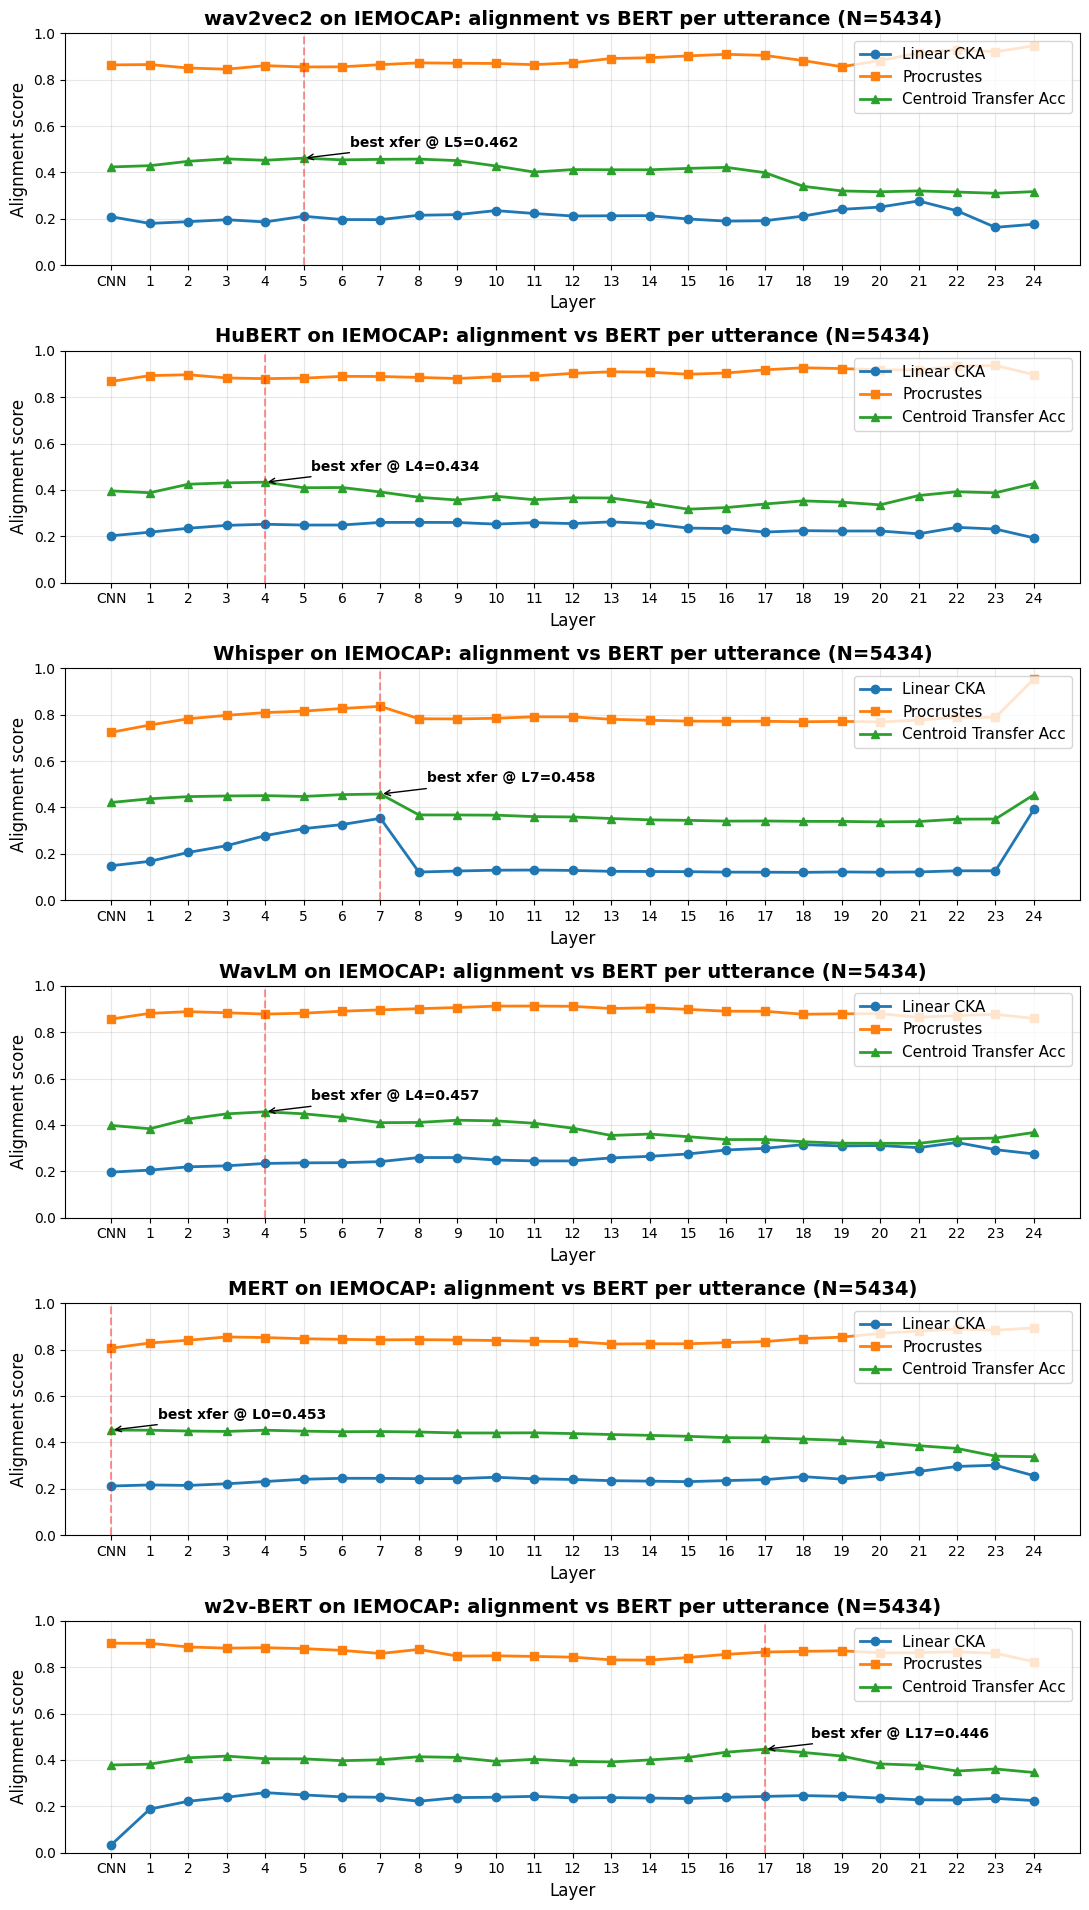

Saved /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/per_model_alignment_curves_transcripts.png


In [8]:
n_models = len(alignment_results)
fig, axes = plt.subplots(n_models, 1, figsize=(11, 3.2 * n_models))
if n_models == 1:
    axes = [axes]

for ax, (model, res) in zip(axes, alignment_results.items()):
    layers = np.arange(NUM_LAYERS)
    ax.plot(layers, res['cka'], marker='o', lw=2, label='Linear CKA')
    ax.plot(layers, res['procrustes'], marker='s', lw=2, label='Procrustes')
    ax.plot(layers, res['centroid_transfer'], marker='^', lw=2, label='Centroid Transfer Acc')
    best = int(np.argmax(res['centroid_transfer']))
    ax.axvline(best, color='red', ls='--', alpha=0.4)
    ax.annotate(
        f'best xfer @ L{best}={res["centroid_transfer"][best]:.3f}',
        xy=(best, res['centroid_transfer'][best]),
        xytext=(best + 1.2, res['centroid_transfer'][best] + 0.05),
        fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='black'),
    )
    ax.set_title(
        f'{model} on IEMOCAP: alignment vs BERT per utterance (N={res["num_samples"]})',
        fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold',
    )
    ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_ylabel('Alignment score', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_xticks(layers)
    ax.set_xticklabels(LAYER_LABELS, fontsize=PLOT_STYLE['tick_fontsize'])
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=PLOT_STYLE['grid_alpha'])
    ax.legend(fontsize=PLOT_STYLE['legend_fontsize'], loc='upper right')

plt.tight_layout()
out_png = os.path.join(RESULTS_DIR, 'per_model_alignment_curves_transcripts.png')
plt.savefig(out_png, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
plt.savefig(out_png.replace('.png', '.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved {out_png}')


## 9. 6-Model x 25-Layer Heatmaps

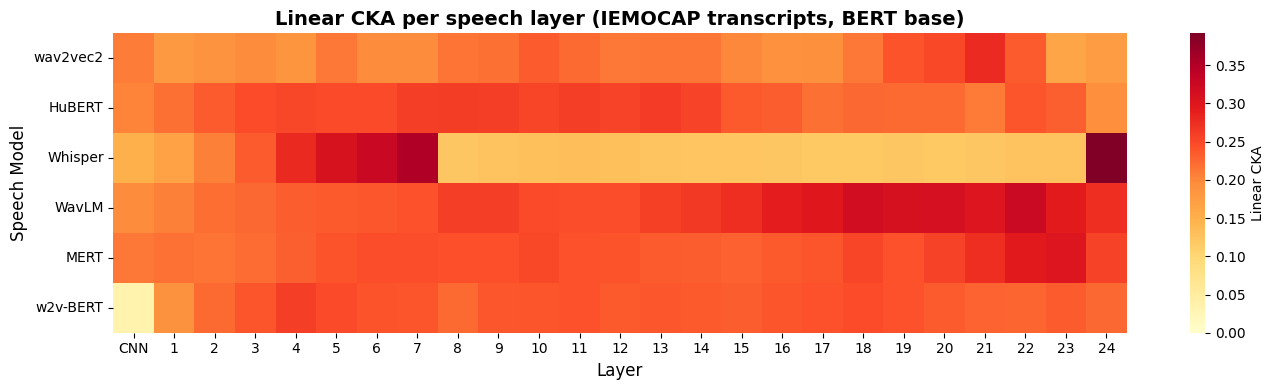

Saved /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/heatmap_cka_transcripts.png


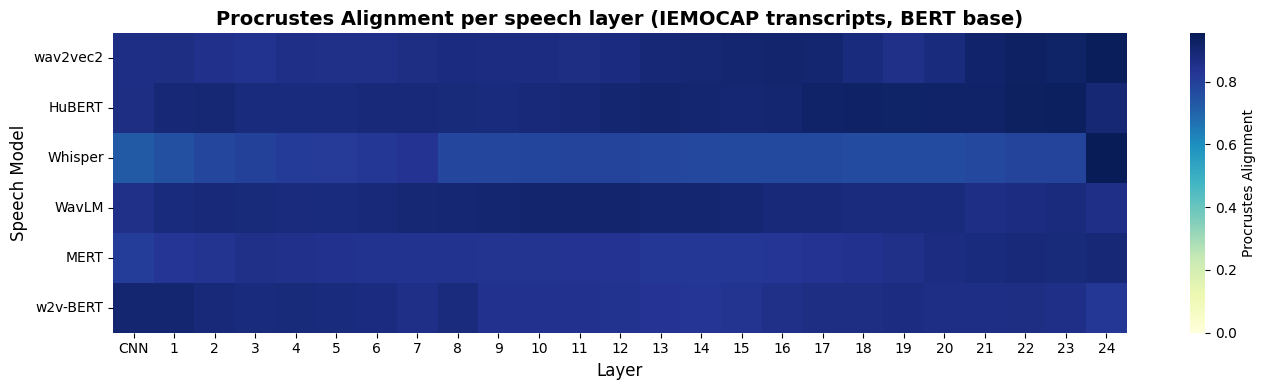

Saved /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/heatmap_procrustes_transcripts.png


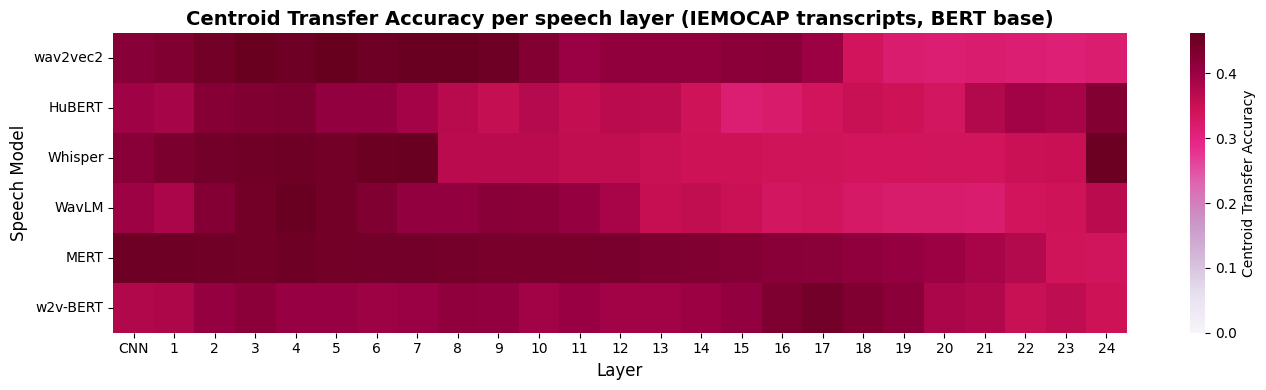

Saved /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/heatmap_transfer_transcripts.png


In [9]:
def plot_heatmap(metric_key, label, cmap, out_name):
    data = np.stack([
        alignment_results[m][metric_key] for m in MODELS if m in alignment_results
    ])
    ordered_models = [m for m in MODELS if m in alignment_results]
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(
        data, cmap=cmap, annot=False, vmin=0, vmax=float(data.max()),
        xticklabels=LAYER_LABELS, yticklabels=ordered_models,
        cbar_kws={'label': label}, ax=ax,
    )
    ax.set_title(
        f'{label} per speech layer (IEMOCAP transcripts, BERT base)',
        fontsize=PLOT_STYLE['title_fontsize'], fontweight='bold',
    )
    ax.set_xlabel('Layer', fontsize=PLOT_STYLE['label_fontsize'])
    ax.set_ylabel('Speech Model', fontsize=PLOT_STYLE['label_fontsize'])
    plt.tight_layout()
    out_png = os.path.join(RESULTS_DIR, out_name)
    plt.savefig(out_png, dpi=PLOT_STYLE['dpi'], bbox_inches='tight')
    plt.savefig(out_png.replace('.png', '.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved {out_png}')


plot_heatmap('cka', 'Linear CKA', 'YlOrRd', 'heatmap_cka_transcripts.png')
plot_heatmap('procrustes', 'Procrustes Alignment', 'YlGnBu', 'heatmap_procrustes_transcripts.png')
plot_heatmap('centroid_transfer', 'Centroid Transfer Accuracy', 'PuRd', 'heatmap_transfer_transcripts.png')


## 10. Save Everything

In [10]:
# 1. Wide per-layer CSV
rows = []
for model, res in alignment_results.items():
    for metric in ('cka', 'procrustes', 'centroid_transfer'):
        row = {'Model': model, 'Metric': metric}
        for li in range(NUM_LAYERS):
            row[f'layer_{li}'] = float(res[metric][li])
        rows.append(row)
wide_df = pd.DataFrame(rows)
wide_path = os.path.join(RESULTS_DIR, 'alignment_transcripts_per_layer_wide.csv')
wide_df.to_csv(wide_path, index=False)
print(f'Saved {wide_path} ({len(wide_df)} rows)')

# 2. Summary CSV: best layer per (model, metric)
summary_rows = []
for model, res in alignment_results.items():
    for metric in ('cka', 'procrustes', 'centroid_transfer'):
        arr = res[metric]
        best = int(np.argmax(arr))
        summary_rows.append({
            'Model': model,
            'Metric': metric,
            'Num_Samples': res['num_samples'],
            'Best_Layer': best,
            'Best_Value': float(arr[best]),
            'CNN_Value': float(arr[0]),
            'Last_Layer_Value': float(arr[-1]),
        })
summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, 'alignment_transcripts_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'Saved {summary_path}')
print()
print(summary_df.to_string(index=False))

# 3. Pickle the raw arrays for downstream analysis
np.savez(
    os.path.join(RESULTS_DIR, 'alignment_transcripts_raw.npz'),
    **{
        f'{m}_{k}': v
        for m, res in alignment_results.items()
        for k, v in res.items()
        if isinstance(v, np.ndarray)
    },
)
print(f'Saved raw arrays to alignment_transcripts_raw.npz')


Saved /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/alignment_transcripts_per_layer_wide.csv (18 rows)
Saved /Users/chaitanyaparwatkar/Desktop/CSCI535-SER-Final/my_code/results/bert_alignment_transcripts/alignment_transcripts_summary.csv

   Model            Metric  Num_Samples  Best_Layer  Best_Value  CNN_Value  Last_Layer_Value
wav2vec2               cka         5434          21    0.277124   0.208853          0.176775
wav2vec2        procrustes         5434          24    0.946005   0.863790          0.946005
wav2vec2 centroid_transfer         5434           5    0.461722   0.423813          0.317446
  HuBERT               cka         5434          13    0.262456   0.202543          0.193497
  HuBERT        procrustes         5434          23    0.937088   0.868027          0.897360
  HuBERT centroid_transfer         5434           4    0.433566   0.396025          0.427678
 Whisper               cka         5434          24    0.3916